# EEG Oddball Visualization

Tập trung vào việc hiển thị ERP tại kênh `Pz` và các đặc trưng P300 đã trích xuất từ `processed_data` và `df_features_bandpower.csv`. Nếu dữ liệu không có sẵn thì phần đó sẽ được bỏ qua.


In [25]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [26]:
def load_processed_data() -> dict:
    """Load processed_data từ file pickle nếu có."""
    candidates = [
        Path("processed_data.pkl"),
        Path.home() / "Downloads" / "processed" / "processed_data.pkl",
    ]

    for candidate in candidates:
        if candidate.exists():
            try:
                with open(candidate, "rb") as handle:
                    data = pickle.load(handle)
                print(f"Loaded processed_data from {candidate}")
                return data
            except Exception as exc:
                print(f"Unable to read {candidate}: {exc}")

    print("processed_data not found -> empty dict")
    return {}


def load_bandpower_features() -> pd.DataFrame:
    """Load bandpower feature CSV nếu có."""
    candidates = [
        Path("df_features_bandpower.csv"),
        Path("features_all_subjects.csv"),
    ]

    for candidate in candidates:
        if candidate.exists():
            try:
                df = pd.read_csv(candidate)
                print(f"Loaded bandpower features from {candidate}")
                return df
            except Exception as exc:
                print(f"Unable to read {candidate}: {exc}")

    print("Bandpower CSV not found -> empty DataFrame")
    return pd.DataFrame()



In [27]:
EVENT_NAMES = {
    "target": ["target", "Stimulus/S  7", "7"],
    "frequent": ["frequent", "Stimulus/S  5", "5"],
}


def _get_epochs_by_name(epochs, alias: str):
    for candidate in EVENT_NAMES.get(alias, []):
        if candidate in epochs.event_id:
            return epochs[candidate]
    raise KeyError(alias)


def plot_erp(processed_data: dict, channel: str = "Pz") -> None:
    if not processed_data:
        print("No processed_data -> skipping ERP plot")
        return

    target_traces, frequent_traces = [], []

    for epochs in processed_data.values():
        if channel not in epochs.ch_names:
            continue
        try:
            target = _get_epochs_by_name(epochs, "target").get_data()[:, epochs.ch_names.index(channel), :]
            frequent = _get_epochs_by_name(epochs, "frequent").get_data()[:, epochs.ch_names.index(channel), :]
        except KeyError:
            continue

        if target.size and frequent.size:
            target_traces.append(target.mean(axis=0))
            frequent_traces.append(frequent.mean(axis=0))

    if not target_traces or not frequent_traces:
        print("Insufficient epochs -> skipping ERP plot")
        return

    grand_target = np.mean(target_traces, axis=0)
    grand_frequent = np.mean(frequent_traces, axis=0)
    times = epochs.times

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    axes[0].plot(times, grand_target * 1e6, color="#d62728", label="Target")
    axes[0].plot(times, grand_frequent * 1e6, color="#1f77b4", label="Frequent")
    axes[0].axvspan(0.25, 0.45, color="gold", alpha=0.3, label="P300 window")
    axes[0].set(title="ERP at Pz", xlabel="Time (s)", ylabel="Amplitude (µV)")
    axes[0].legend()

    diff = (grand_target - grand_frequent) * 1e6
    axes[1].plot(times, diff, color="#2ca02c")
    axes[1].fill_between(times, 0, diff, where=diff > 0, color="#2ca02c", alpha=0.3)
    axes[1].set(title="Difference wave", xlabel="Time (s)", ylabel="Target - Frequent (µV)")

    plt.tight_layout()
    plt.show()


def plot_p300_from_csv(df: pd.DataFrame) -> None:
    if df.empty:
        print("Bandpower features missing -> skip CSV-based plot")
        return

    if "p300_peak_amp" not in df.columns:
        print("p300_peak_amp column missing -> skip")
        return

    df = df[df["label"].isin(["Stimulus/S  5", "Stimulus/S  7"])]
    pivot = (
        df.pivot_table(index="subject_id", columns="label", values="p300_peak_amp", aggfunc="mean")
        .rename(columns={"Stimulus/S  5": "Frequent", "Stimulus/S  7": "Target"})
        * 1e6
    )

    ax = pivot.plot.bar(figsize=(10, 5))
    ax.set_title("Mean P300 Peak Amplitude (µV)")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid(axis="y", alpha=0.4)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Loaded processed_data from C:\Users\VUONG\Downloads\processed\processed_data.pkl
Loaded bandpower features from features_all_subjects.csv


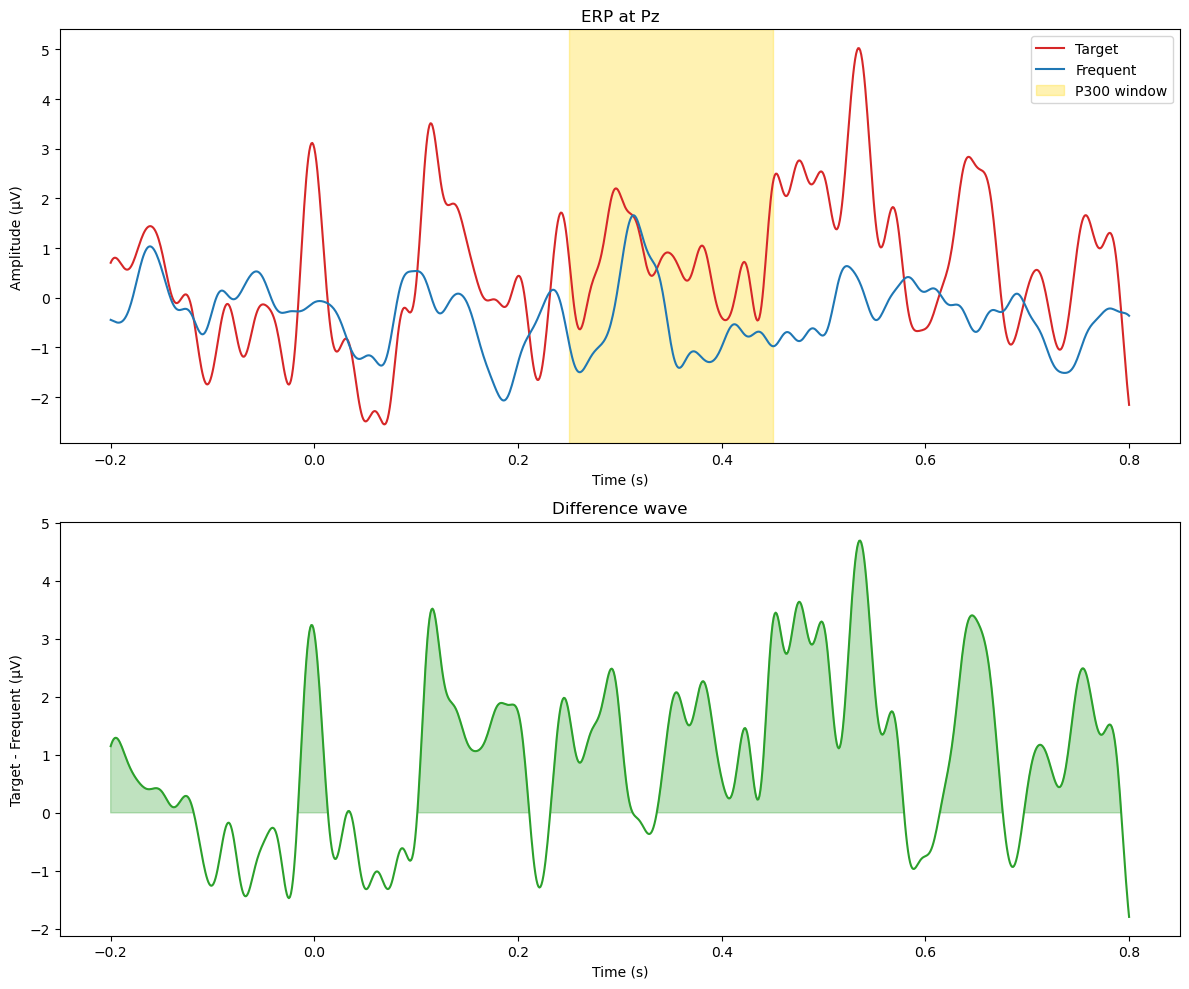

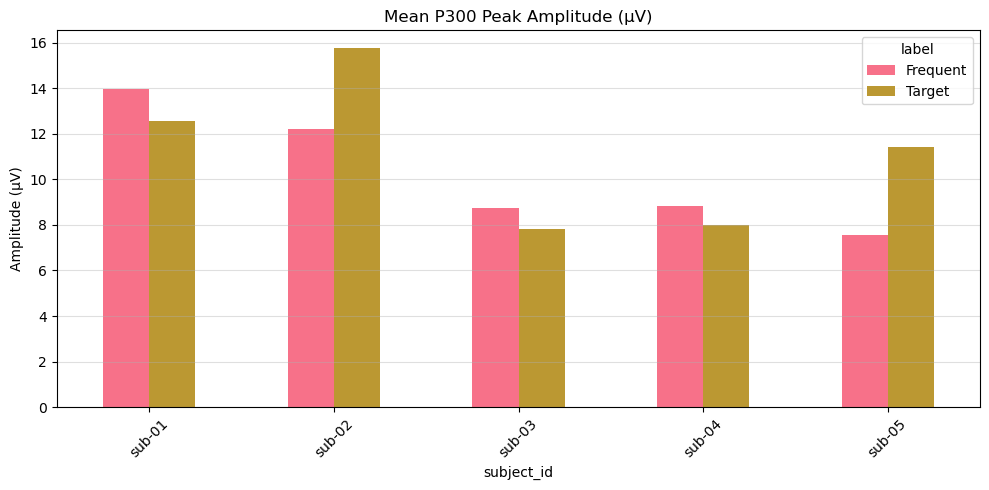

In [28]:
processed_data = load_processed_data()
df_bandpower = load_bandpower_features()

plot_erp(processed_data)
plot_p300_from_csv(df_bandpower)


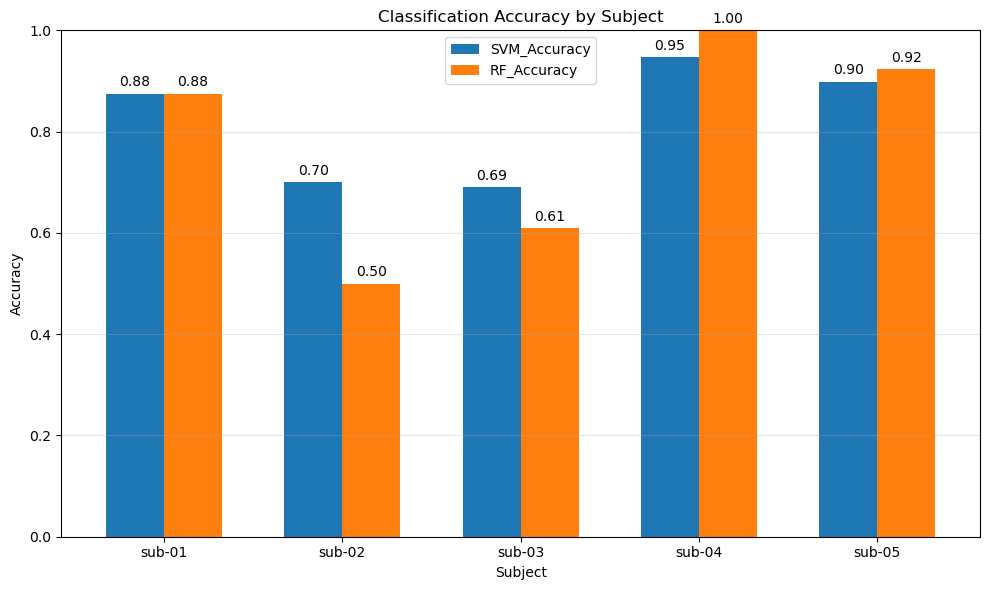

In [30]:
accuracy_path = Path("final_accuracy_comparison_with_status.csv")
if not accuracy_path.exists():
    alt = Path.home() / "Downloads" / "final_accuracy_comparison_with_status.csv"
    if alt.exists():
        accuracy_path = alt

if not accuracy_path.exists():
    print("Accuracy comparison file not found -> skipping bar chart")
else:
    df_acc = pd.read_csv(accuracy_path)
    df_plot = df_acc.set_index("Subject")[["SVM_Accuracy", "RF_Accuracy"]]

    ax = df_plot.plot.bar(figsize=(10, 6), width=0.65, color=["#1f77b4", "#ff7f0e"])
    ax.set_ylabel("Accuracy")
    ax.set_title("Classification Accuracy by Subject")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v:.2f}" for v in container.datavalues], padding=3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()